# Analysis of Daily Activity Dataset

### Overview
Detailed analysis of daily activity data, including trend visualizations, descriptive statistics, and correlation analysis, along with inferences and future recommendations.

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
import numpy as np

# Load the dataset
file_path = 'Daily_Activity_metrics_filled3.csv'
data = pd.read_csv(file_path)

# Convert 'Date' column to datetime format for consistency in time-based analysis
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')


## Data Overview

In [69]:
data.head()

,Date,Move Minutes count,Calories (kcal),Distance (m),Average heart rate (bpm),Max heart rate (bpm),Min heart rate (bpm),Average speed (m/s),Max speed (m/s),Min speed (m/s),Step count,Walking duration (ms)
0,2024-08-12,181.0,1454.5,4389.756115,88.933775,115.0,66.0,0.386543,0.478343,0.324931,10244.0,1.294051e+06
1,2024-08-13,180.0,1454.5,4193.930564,83.816770,105.0,66.0,0.415036,0.509161,0.313160,11040.0,1.265334e+06
2,2024-08-14,60.0,1454.5,1700.920657,85.792398,127.0,67.0,0.469593,0.469593,0.469593,10810.0,3.093364e+05
3,2024-08-15,61.0,1454.5,3015.839024,79.345745,118.0,57.0,0.417125,0.540696,0.293554,8100.0,1.025848e+06
4,2024-08-17,61.0,1454.5,1317.428951,84.850410,105.0,62.0,0.355202,0.355202,0.355202,8975.0,9.349274e+05


In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      84 non-null     datetime64[ns]
 1   Move Minutes count        82 non-null     float64       
 2   Calories (kcal)           84 non-null     float64       
 3   Distance (m)              84 non-null     float64       
 4   Average heart rate (bpm)  84 non-null     float64       
 5   Max heart rate (bpm)      84 non-null     float64       
 6   Min heart rate (bpm)      84 non-null     float64       
 7   Average speed (m/s)       84 non-null     float64       
 8   Max speed (m/s)           84 non-null     float64       
 9   Min speed (m/s)           84 non-null     float64       
 10  Step count                84 non-null     float64       
 11  Walking duration (ms)     82 non-null     float64       
dtypes: datetime64[ns](1), fl

# Data Cleaning
#### Days When I didn't wore watch!
- Identify
- Replace with nan

In [71]:
threshold=1000
steps_below_threshold = data[data['Step count'] < threshold].shape[0]
print(f"Number of steps below {threshold}: {steps_below_threshold}")

Number of steps below 1000: 8


In [72]:
data.loc[data['Step count'] < threshold, 'Step count'] = np.nan

- Identify Missing values

In [73]:
data.isna().sum()

Date                        1
Move Minutes count          3
Calories (kcal)             1
Distance (m)                1
Average heart rate (bpm)    1
Max heart rate (bpm)        1
Min heart rate (bpm)        1
Average speed (m/s)         1
Max speed (m/s)             1
Min speed (m/s)             1
Step count                  9
Walking duration (ms)       3
dtype: int64

- Imputing Missing values

In [74]:
# Ensure 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'], infer_datetime_format=True)

# Drop rows where 'Date' is missing
data = data.dropna(subset=['Date'])

# Calculate the mean for each field by day of the week
mean_values_by_day = data.groupby(data['Date'].dt.day_name()).mean()

# Function to replace missing values with the mean of the corresponding day of the week
def replace_with_mean(row):
    for column in data.columns:
        if pd.isna(row[column]):
            row[column] = mean_values_by_day.loc[row['Date'].day_name(), column]
    return row

# Apply the function to the dataframe
df = data.apply(replace_with_mean, axis=1)


## Descriptive Statistics

In [75]:
df.describe()

,Date,Move Minutes count,Calories (kcal),Distance (m),Average heart rate (bpm),Max heart rate (bpm),Min heart rate (bpm),Average speed (m/s),Max speed (m/s),Min speed (m/s),Step count,Walking duration (ms)
count,84,84.000000,84.000000,84.000000,84.000000,84.000000,84.00000,84.000000,84.000000,84.000000,84.000000,8.400000e+01
mean,2024-09-30 14:00:00,80.952381,1706.009247,3361.831966,92.251846,116.476190,67.77381,0.537877,1.417106,0.277109,5968.274531,1.371392e+06
min,2024-08-12 00:00:00,3.000000,1454.500000,58.738222,79.345745,97.000000,56.00000,0.289687,0.289687,0.243344,1016.000000,1.146354e+04
25%,2024-09-08 18:00:00,30.000000,1659.249949,1072.261587,87.959691,111.750000,64.75000,0.457759,1.238619,0.250158,2533.000000,3.426063e+05
50%,2024-09-29 12:00:00,69.500000,1672.615471,3257.326568,93.501526,117.000000,67.50000,0.539631,1.498901,0.261528,5559.111111,9.127517e+05
75%,2024-10-24 06:00:00,119.000000,1795.101070,4984.978402,96.472691,120.250000,71.00000,0.624686,1.627225,0.285624,9005.500000,1.931286e+06
max,2024-11-15 00:00:00,252.000000,2043.661751,10130.592509,106.611511,144.000000,91.00000,0.753153,2.872956,0.469593,15598.000000,5.505097e+06
std,NaN,56.356418,141.500606,2306.366959,5.773845,7.624432,5.84406,0.111825,0.518207,0.041074,3645.463467,1.369219e+06


## Plot: Daily Step Count Over Time

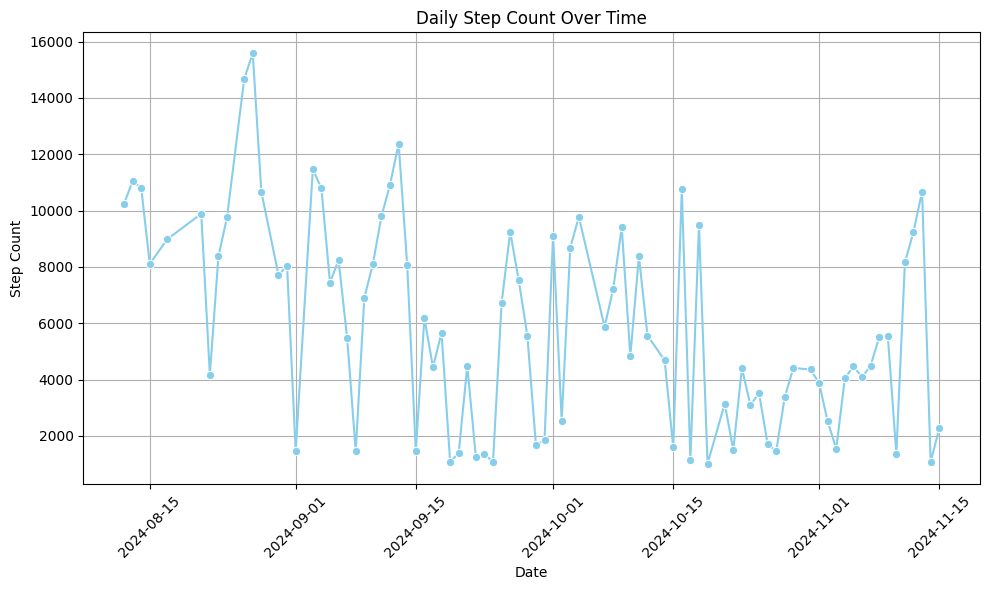

In [76]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Date', y='Step count', data=df, marker='o', color='skyblue')
plt.xlabel('Date')
plt.ylabel('Step Count')
plt.title('Daily Step Count Over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

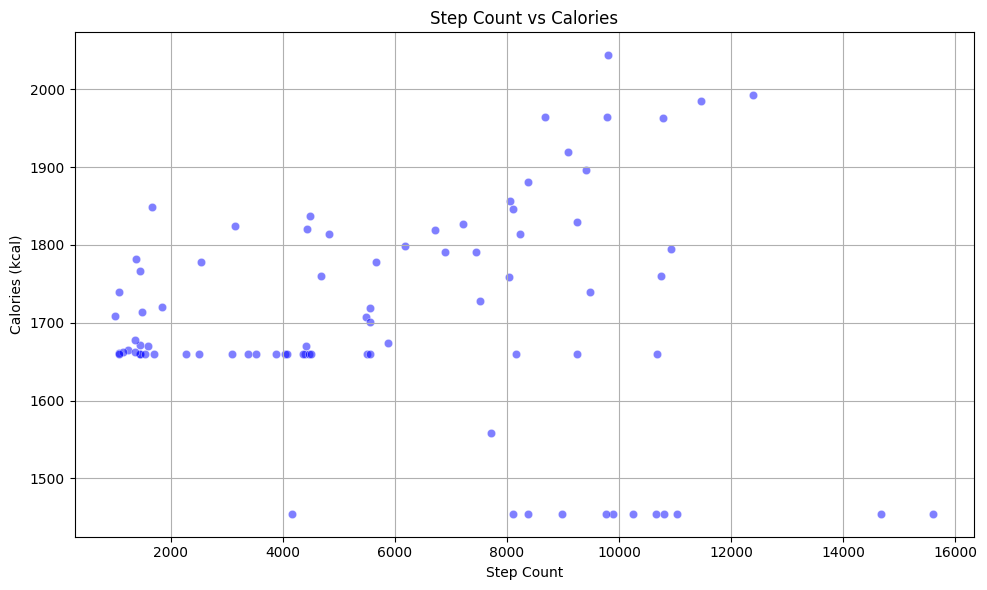

In [77]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Step count', y='Calories (kcal)', data=df,color='blue', alpha=0.5)
plt.xlabel('Step Count')
plt.ylabel('Calories (kcal)')
plt.title('Step Count vs Calories')
plt.grid(True)
plt.tight_layout()
plt.show()

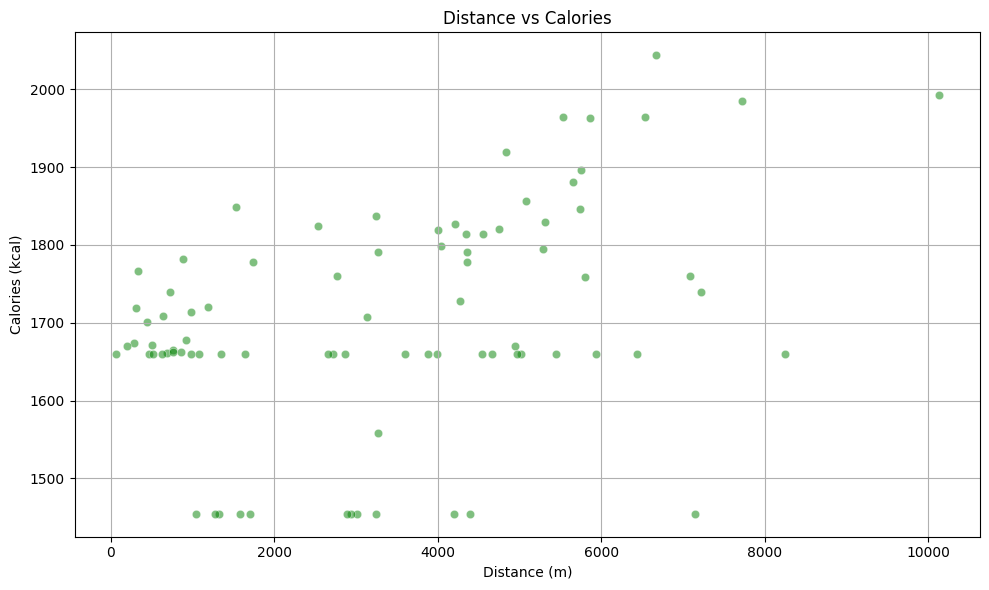

In [78]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Distance (m)', y='Calories (kcal)', data=df,color='green', alpha=0.5)
plt.xlabel('Distance (m)')
plt.ylabel('Calories (kcal)')
plt.title('Distance vs Calories')
plt.grid(True)
plt.tight_layout()
plt.show()

In [79]:
average_steps_per_day = df.groupby(data['Date'].dt.day_name())['Step count'].mean()
print(average_steps_per_day.sort_values())

Date
Sunday       1457.750000
Thursday     5279.000000
Saturday     5559.111111
Monday       5873.727273
Friday       6801.538462
Tuesday      6865.538462
Wednesday    8167.692308
Name: Step count, dtype: float64


In [80]:
holiday_threshold=1500
# Filter the dataframe for step counts below holiday threshold
days_below_3000 = df[df['Step count'] < holiday_threshold]

# Extract the day of the week for these days
days_below_3000['Day of Week'] = days_below_3000['Date'].dt.day_name()

# Get the frequency of each day of the week
day_frequency = days_below_3000['Day of Week'].value_counts()
print("------------Days Counts below 3000 steps------------")
print(day_frequency)

------------Days Counts below 3000 steps------------
Day of Week
Sunday      6
Thursday    3
Tuesday     2
Friday      1
Monday      1
Saturday    1
Name: count, dtype: int64


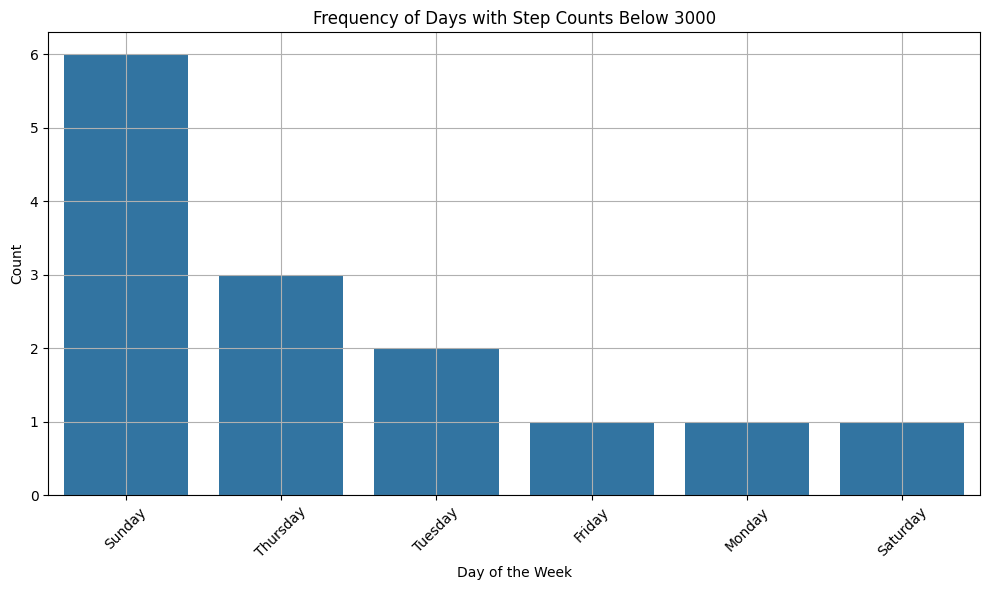

In [81]:
# Convert the Series to a DataFrame and reset the index
day_frequency_df = day_frequency.reset_index()
day_frequency_df.columns = ['Day of the Week', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Day of the Week', y='Count', data=day_frequency_df)
plt.xlabel('Day of the Week')
plt.ylabel('Count')
plt.title('Frequency of Days with Step Counts Below 3000')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Correlation Analysis

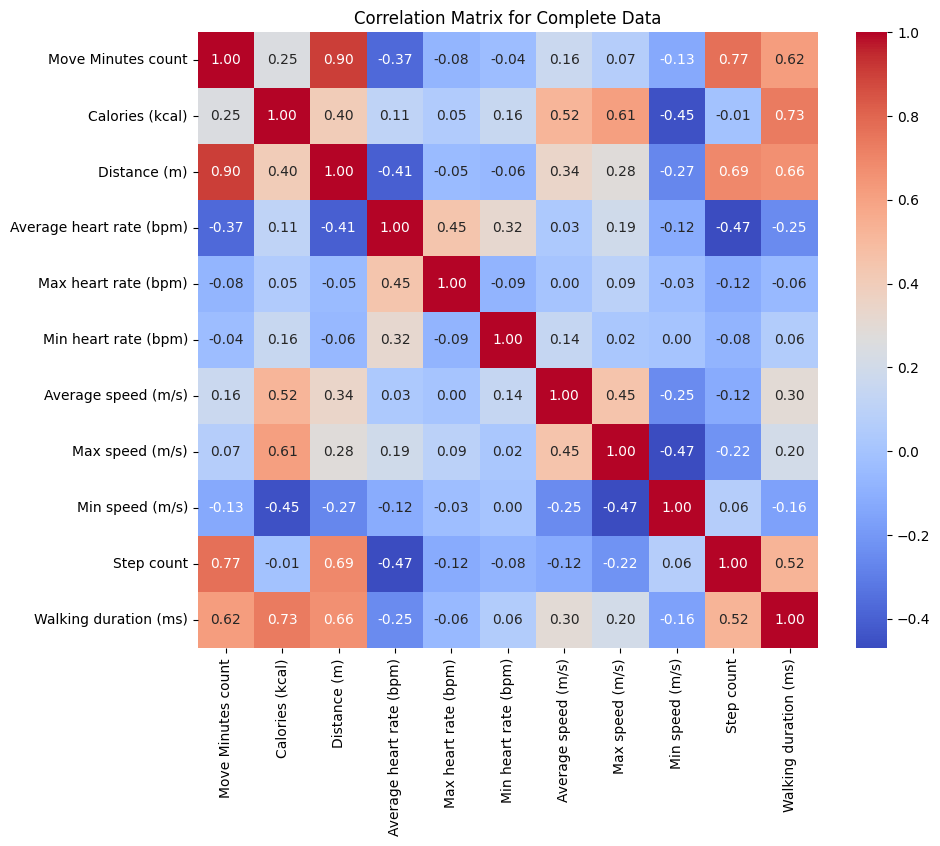

In [82]:
corr_data=df.drop(['Date'], axis=1)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix for Complete Data")
plt.show()
    


# Summary of Analysis

### Intuition, Objectives, and Challenges

**Intuition**: The dataset captures daily metrics related to physical activity, useful for tracking health and fitness patterns.

**Objectives**: Monitor activity levels, identify high-activity days, and assess calorie burn.

**Challenges**: Handling missing data, ensuring data consistency, and interpreting correlations carefully.

### Inferences
- Higher step counts and speeds correlate with higher calorie burn.
- Heart rate data shows varying cardiovascular effort, helpful for fitness planning.
- Activity levels fluctuate, with some days showing peak activity.

### Future Scope
1. **Time-Series Analysis** for trends and goal-setting.
2. **Predictive Modeling** for calorie and activity forecasting.
3. **Activity Classification** to label sedentary vs. active days.
4. **Personalized Recommendations** for fitness or dietary guidance.
    